In [29]:
# Dataset exploration
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(
    version="v1.0-mini",
    dataroot="../data/nuscenes",
    verbose=True
)

print(len(nusc.scene))

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.124 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
10


In [30]:
# Load the first scene

scene = nusc.scene[0]
print(scene["name"])

scene-0061


In [32]:
# Fetch the first sample in the scene

sample = nusc.get(
    "sample",
    scene["first_sample_token"]
)

sample["data"].keys()

dict_keys(['RADAR_FRONT', 'RADAR_FRONT_LEFT', 'RADAR_FRONT_RIGHT', 'RADAR_BACK_LEFT', 'RADAR_BACK_RIGHT', 'LIDAR_TOP', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_RIGHT', 'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_FRONT_LEFT'])

In [ ]:
# Load camera image

import os
import cv2
import matplotlib.pyplot as plt

camera_token = sample["data"]["CAM_FRONT"]
camera_data = nusc.get("sample_data", camera_token)
print(camera_data["filename"])

img_path = os.path.join(
    nusc.dataroot,
    camera_data["filename"]
)

image = cv2.imread(img_path)

if image is None:
    raise FileNotFoundError(img_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.imshow(image)
plt.axis("off")
plt.show()


In [41]:
# Load LiDAR point cloud

from nuscenes.utils.data_classes import LidarPointCloud

lidar_token = sample["data"]["LIDAR_TOP"]

lidar_data = nusc.get(
    "sample_data",
    lidar_token
)
lidar_path = os.path.join(
    nusc.dataroot,
    lidar_data["filename"]
)

print(lidar_path)

pc = LidarPointCloud.from_file(
    lidar_path
)

print(pc.points.shape)

../data/nuscenes/samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
(4, 34688)


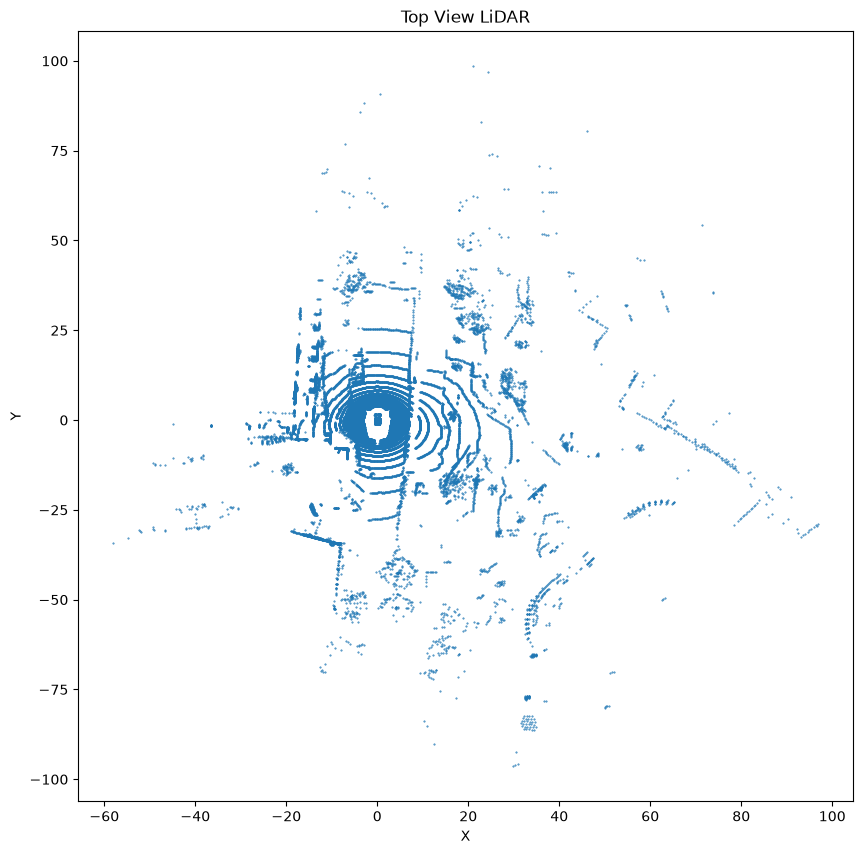

In [42]:
# Visualize the point cloud


plt.figure(figsize=(10,10))

plt.scatter(
    pc.points[0,:],
    pc.points[1,:],
    s=0.2
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Top View LiDAR")
plt.show()

In [ ]:
# Understand calibration data

cam_calib = nusc.get(
    "calibrated_sensor",
    camera_data["calibrated_sensor_token"]
)

cam_calib.keys()


dict_keys(['token', 'sensor_token', 'translation', 'rotation', 'camera_intrinsic'])

In [47]:
# LiDAR Calibration

lidar_calib = nusc.get(
    "calibrated_sensor",
    lidar_data["calibrated_sensor_token"]
)

lidar_calib["translation"]

[0.943713, 0.0, 1.84023]

In [50]:
# Ego Pose

ego_pose = nusc.get(
    "ego_pose",
    camera_data["ego_pose_token"]
)

ego_pose.keys()

dict_keys(['token', 'timestamp', 'rotation', 'translation'])